# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

### Общая информация ###

Дата выдачи: 16.04.2026

Мягкий дедлайн: 30.04.2026 23:59

Жесткий дедлайн:  05.05.2026 23:59

### О задании

В процессе выполнения этого домашнего задания вы:

1. Попрактикуетесь использовать решающие деревья из `sklearn` для задачи классификации на простых двумерных датасетах, научитесь визуализировать разделяющие плоскости и распознавать переобучение.

2. Реализуете своё решающее дерево для задачи классификации и сравните его со стандартной имплементацией.

3. Исследуете влияние бэггинга на смещение и разброс.

### Оценивание и штрафы

Каждая из задач имеет определенную стоимость, которая указана в скобках около номера задачи. Максимально допустимая оценка за работу $-$ 10 баллов.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.


### Формат сдачи

Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Номера лучших посылок в [Яндекс.Контесте](https://new.contest.yandex.ru/contests/72204/start) для обеих задач

В [Яндекс.Контест](https://new.contest.yandex.ru/contests/72204/start) нужно отправить файл hw5code.py с реализованными функциями и классами.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__ 8,5

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [83]:
def plot_decision_surface(axis, model, X, y, title, grid_step=0.02):
    X = np.asarray(X)
    y = _as_numpy_1d(y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx0, xx1 = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step),
    )
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    surface = np.asarray(model.predict(grid)).reshape(xx0.shape)

    axis.contourf(xx0, xx1, surface, alpha=0.25, cmap="coolwarm")
    axis.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20)
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_min, y_max)
    axis.set_title(title)
    axis.set_xlabel("feature 1")
    axis.set_ylabel("feature 2")

## Решающие деревья

### Визуализация (1 балл)

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [84]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

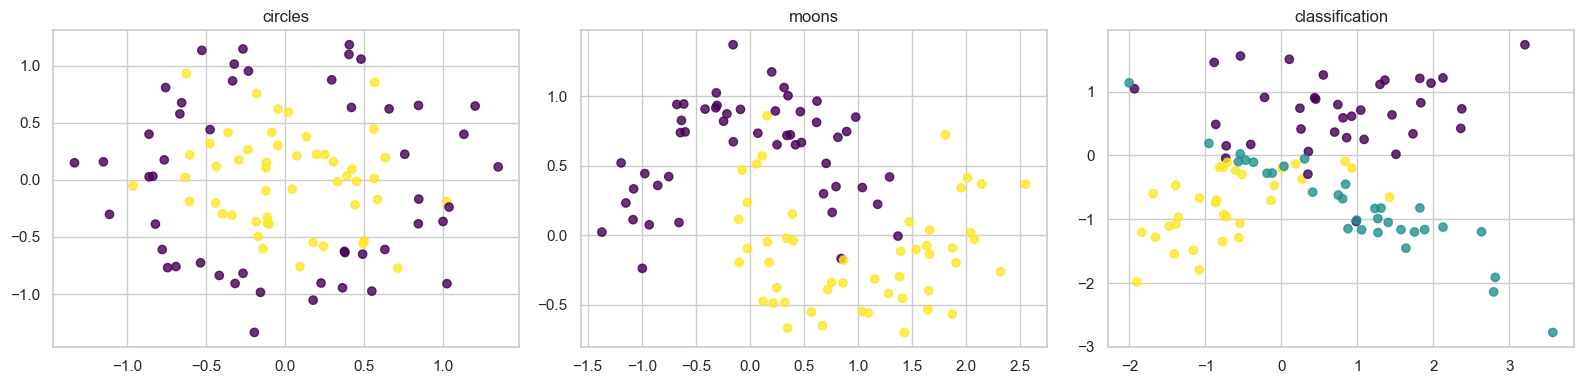

In [85]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)
    plt.title(["circles", "moons", "classification"][i])
plt.tight_layout()
plt.show()

__Задание 1. (0.5 балла)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности и посчитайте accuracy на обучающей и тестовой выборках. Прокомментируйте, в каких случаях и почему модель переобучается.

,dataset,train_accuracy,test_accuracy
0,circles,1.0,0.933333
1,moons,1.0,0.833333
2,classification,1.0,0.833333


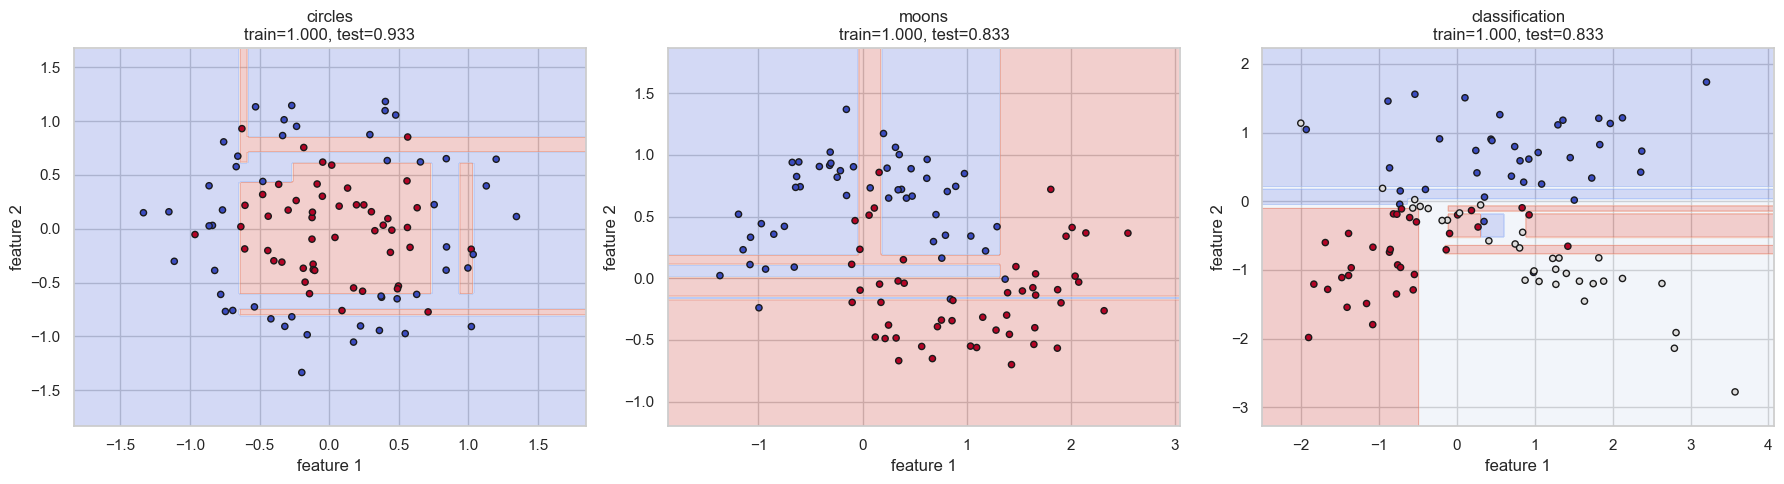

In [86]:
from sklearn.metrics import accuracy_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
summary_rows = []

for axis, (features, target), dataset_name in zip(axes, datasets, ["circles", "moons", "classification"]):
    stratify = target if np.unique(target).size > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        target,
        test_size=0.3,
        random_state=0,
        stratify=stratify,
    )
    tree = DecisionTreeClassifier(random_state=0)
    tree.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, tree.predict(X_train))
    test_accuracy = accuracy_score(y_test, tree.predict(X_test))
    summary_rows.append((dataset_name, train_accuracy, test_accuracy))
    plot_decision_surface(
        axis,
        tree,
        features,
        target,
        f"{dataset_name}\ntrain={train_accuracy:.3f}, test={test_accuracy:.3f}",
    )

plt.tight_layout()
summary = pd.DataFrame(summary_rows, columns=["dataset", "train_accuracy", "test_accuracy"])
summary


На шумных нелинейных датасетах дерево без ограничений почти всегда переобучается: оно может нарезать пространство на очень мелкие области и почти идеально запомнить обучающую выборку, поэтому train accuracy оказывается высокой, а test accuracy заметно ниже. На более простых данных переобучение слабее, но для дерева по умолчанию оно все равно обычно заметно, потому что глубина не ограничена и модель очень гибкая.

__Задание 2. (0.5 балла)__

Выберите один датасет из предыдущего задания и исследуйте на его примере влияние на итоговое качество двух гиперпараметров (любых на ваш выбор) одновременно. Для каждой пары значений посчитайте accuracy на обучающей и тестовой выборках и сохраните результаты в таблицу.

Визуализируйте зависимость качества на тестовой выборке от значений выбранных вами гиперпараметров. При каких значениях наблюдается лучшее соотношение разброса и смещения? Почему вы сделали такой вывод?

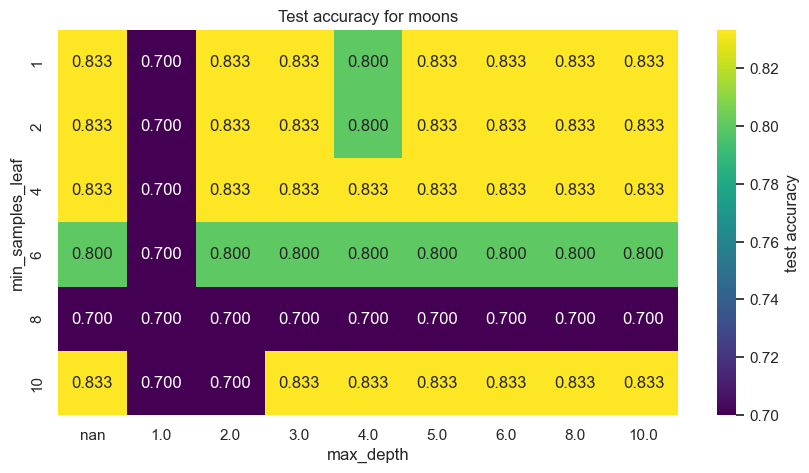

In [87]:
dataset_name = "moons"
features, target = datasets[1]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.3,
    random_state=0,
    stratify=target,
)

rows = []
for max_depth in [1, 2, 3, 4, 5, 6, 8, 10, None]:
    for min_samples_leaf in [1, 2, 4, 6, 8, 10]:
        tree = DecisionTreeClassifier(
            random_state=0,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
        )
        tree.fit(X_train, y_train)
        rows.append(
            {
                "max_depth": max_depth if max_depth is not None else -1,
                "min_samples_leaf": min_samples_leaf,
                "train_accuracy": accuracy_score(y_train, tree.predict(X_train)),
                "test_accuracy": accuracy_score(y_test, tree.predict(X_test)),
            }
        )

results = pd.DataFrame(rows)
results["max_depth"] = results["max_depth"].replace(-1, np.nan)
results

pivot = results.pivot(index="min_samples_leaf", columns="max_depth", values="test_accuracy")
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label": "test accuracy"})
plt.title("Test accuracy for moons")
plt.ylabel("min_samples_leaf")
plt.xlabel("max_depth")
plt.show()


Лучшее соотношение разброса и смещения обычно достигается при умеренной глубине дерева и ненулевом `min_samples_leaf`: модель уже умеет описывать нелинейную границу, но еще не начинает запоминать шум в обучающей выборке. Слишком маленькие ограничения дают почти идеальный train accuracy и ухудшение на test, а слишком сильные ограничения делают модель слишком грубой и ухудшают качество на обеих выборках.

### Решающие деревья своими руками (6 баллов)

Итак, пришло время реализовать свой класс для обучения решающего дерева.

__Задание 3. (1.5 балла)__

Реализуйте функцию `find_best_split` из модуля `hw5code.py` согласно алгоритму, расказанному на лекции; её сигнатура и докстринг с дополнительными требованиями и указаниями прописаны в файле.

Напоминаем, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R, R_l, R_r) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности Джини для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.


__Задание 4. (0.75 балл)__

Загрузите датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Поработайте с данными: создайте бинарный признак `pass`, который будет равен единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выберите пять числовых признаков, среди которых должны быть как очень информативные, так и потенциально неинформативные. Коротко обоснуйте свой выбор.

Для каждого из выбранных признаков постройте график зависимости критерия Джини от возможного порога разделения. Отобразите все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализируйте зависимость
"значение признака - класс (0/1)".

> Можно, например, построить scatter-график, где по оси X - значение признака, а по оси Y - бинарный признак `pass` (при необходимости используйте небольшой jitter по оси Y и/или прозрачность alpha, чтобы лучше видеть плотность точек); или использовать эквивалентную по смыслу визуализацию (например, `seaborn.stripplot` / `swarmplot`), из которой видно, как распределены значения признака внутри каждого класса.

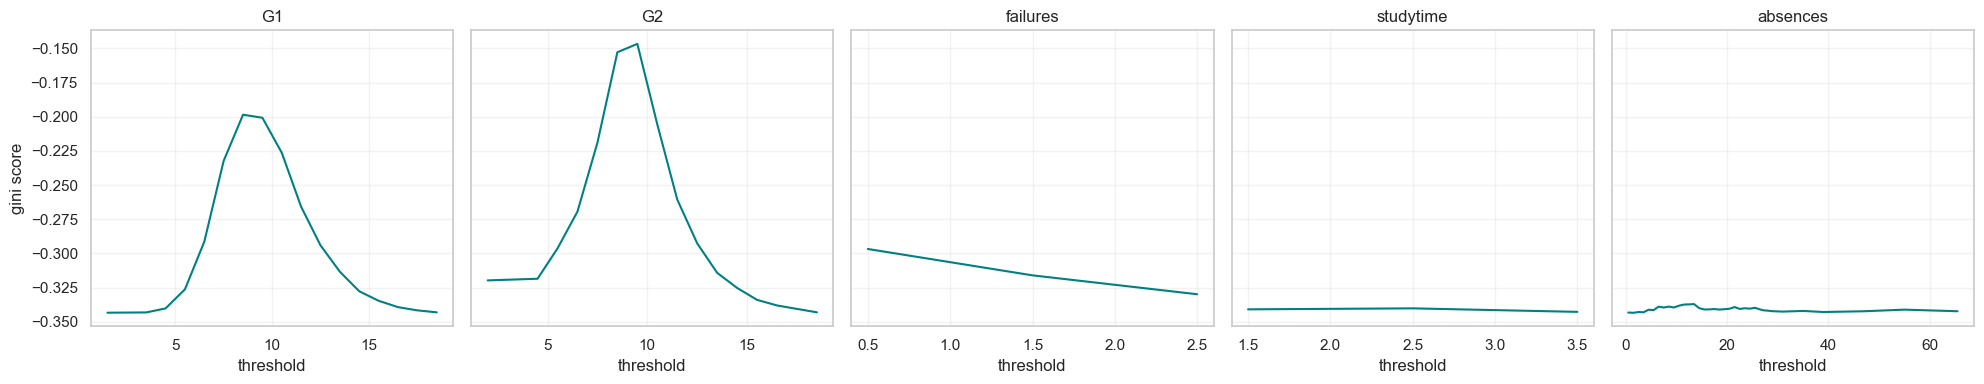

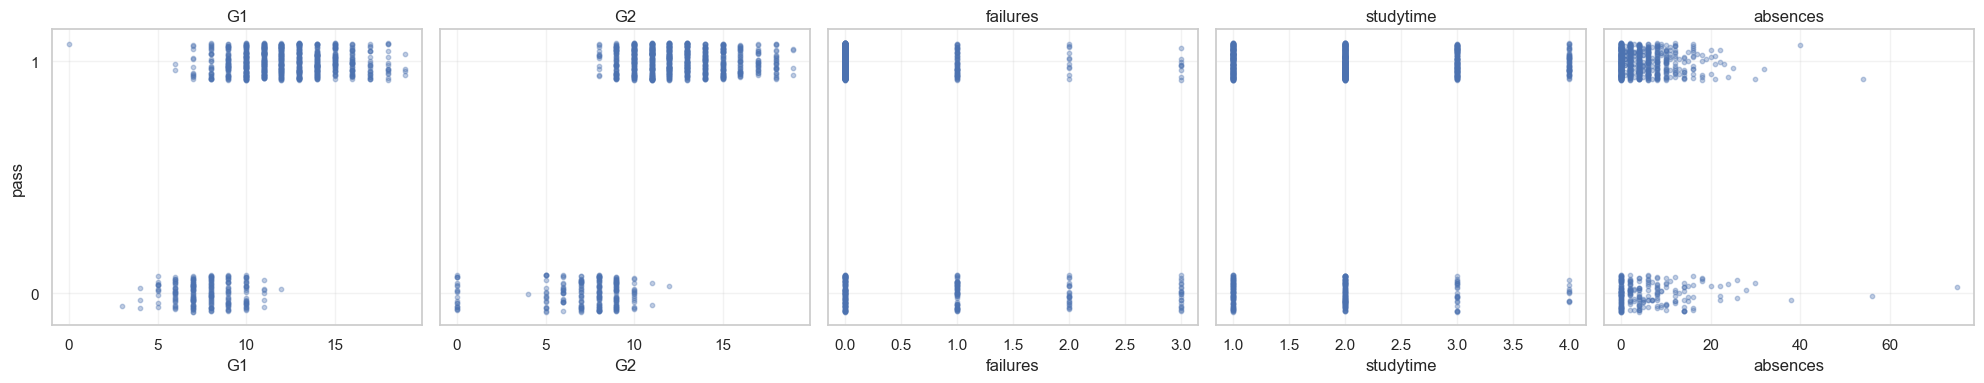

,feature,why
0,G1,very informative
1,G2,very informative
2,failures,moderately informative
3,studytime,moderately informative
4,absences,weakly informative


In [88]:
from pathlib import Path
import io
import zipfile


def load_student_performance():
    roots = [Path.cwd(), Path.home() / "Downloads"]
    for root in roots:
        csv_paths = sorted(root.glob("student-*.csv"))
        if csv_paths:
            return pd.concat([pd.read_csv(path, sep=';') for path in csv_paths], ignore_index=True)
        zip_paths = sorted(root.glob("student*performance*.zip")) + sorted(root.glob("student*.zip"))
        for zip_path in zip_paths:
            with zipfile.ZipFile(zip_path) as outer_zip:
                inner_names = [name for name in outer_zip.namelist() if name.endswith(".zip")]
                if not inner_names:
                    continue
                inner_bytes = outer_zip.read(inner_names[0])
            with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner_zip:
                csv_names = [name for name in inner_zip.namelist() if name.endswith(".csv")]
                if csv_names:
                    return pd.concat([pd.read_csv(inner_zip.open(name), sep=';') for name in csv_names], ignore_index=True)
    raise FileNotFoundError("student performance files were not found")


def gini_curve(feature, target):
    feature = np.asarray(feature)
    target = np.asarray(target)
    order = np.argsort(feature)
    feature = feature[order]
    target = target[order]
    thresholds = (np.unique(feature)[:-1] + np.unique(feature)[1:]) / 2
    scores = []
    for threshold in thresholds:
        left = feature <= threshold
        right = ~left
        scores.append(-(left.mean() * _gini_impurity(target[left]) + right.mean() * _gini_impurity(target[right])))
    return thresholds, np.array(scores)


df = load_student_performance()
df['pass'] = (df['G3'] >= 10).astype(int)

feature_names = ['G1', 'G2', 'failures', 'studytime', 'absences']

fig, axes = plt.subplots(1, len(feature_names), figsize=(20, 4), sharey=True)
for axis, name in zip(axes, feature_names):
    thresholds, scores = gini_curve(df[name], df['pass'])
    axis.plot(thresholds, scores, color='teal')
    axis.set_title(name)
    axis.set_xlabel('threshold')
    axis.grid(alpha=0.25)
axes[0].set_ylabel('gini score')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(feature_names), figsize=(20, 4), sharey=True)
for axis, name in zip(axes, feature_names):
    jitter = np.random.uniform(-0.08, 0.08, size=len(df))
    axis.scatter(df[name], df['pass'] + jitter, s=10, alpha=0.35)
    axis.set_title(name)
    axis.set_xlabel(name)
    axis.set_yticks([0, 1])
    axis.grid(alpha=0.25)
axes[0].set_ylabel('pass')
plt.tight_layout()
plt.show()

info = pd.DataFrame({'feature': feature_names, 'why': ['very informative', 'very informative', 'moderately informative', 'moderately informative', 'weakly informative']})
info

__Ответ:__

Бинарный признак `pass` задаю как `pass = 1`, если `G3 >= 10`, и `pass = 0` иначе.

В качестве признаков беру `G1`, `G2`, `failures`, `studytime`, `absences`. `G1` и `G2` обычно самые информативные, потому что это промежуточные оценки, близкие к итоговой. `failures` тоже полезен, так как число прошлых неудач обычно связано с итоговым результатом. `studytime` и `absences` оставляю как менее информативные признаки.

__Задание 5. (0.25 балла)__

На основании построенных в прошлом задании графиков ответьте на следующие вопросы:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

__Ответ:__

1. По графикам лучше всего делить по признаку G2: у него самый выраженный минимум критерия Джини, значит, он дает наиболее чистое разбиение.

2. Да, совпадает со scatter-графиками: по G2 и G1 классы видны лучше, а по failures, studytime и absences разделение слабее.

3. Для хорошо разделяющих признаков кривая имеет глубокий минимум, а для слабых признаков она более плоская и без явного хорошего порога.

__Задание 6. (1.5 балла)__

Разберитесь с уже написанным кодом в классе `DecisionTree` модуля `hw5code.py`. Исправьте ошибки в методе `_fit_node`, а также реализуйте `_predict_node`.

В данном задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения необходимо производить по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (можете найти его в конспекте в разделе «Учёт категориальных признаков»)

__Задание 7. (0.5 балла)__

Протестируйте написанное вами решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого необходимо скачать таблицу agaricus-lepiota.data и применить к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в рассматриваемой таблице $-$ это целевая переменная ('e' $-$ edible, 'p' $-$ poisonous).

Обучите решающее дерево на $50\%$ случайно выбранных объектов и получите предсказания для оставшейся половины. Вычислите accuracy. Если в предыдущих заданиях вы всё сделали корректно, то у вас должно получиться качество очень близкое единице или даже равное ей.

In [104]:
spec = importlib.util.spec_from_file_location("hw5code", r"d:\VS Code Pr\ML_Homework\Homework 5\hw5code.py")
hw5code = importlib.util.module_from_spec(spec)
spec.loader.exec_module(hw5code)
DecisionTree = hw5code.DecisionTree

mushroom_path = Path(r"d:\VS Code Pr\ML_Homework\Homework 5\mushroom\agaricus-lepiota.data")
if not mushroom_path.exists():
    raise FileNotFoundError("agaricus-lepiota.data was not found in the Homework 5 mushroom folder")

column_names = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape",
    "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color", "population", "habitat",
]

df = pd.read_csv(mushroom_path, header=None, names=column_names)
for column in df.columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column].astype(str))

X = df.drop(columns=["class"]).to_numpy()
y = df["class"].to_numpy()

indices = np.random.permutation(len(df))
midpoint = len(df) // 2
train_indices = indices[:midpoint]
test_indices = indices[midpoint:]

model = DecisionTree(["categorical"] * X.shape[1])
model.fit(X[train_indices], y[train_indices])
predictions = model.predict(X[test_indices])
accuracy = (predictions == y[test_indices]).mean()
accuracy

np.float64(0.5952732644017725)

__Задание 8. (1 балл)__

Реализуйте в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `sklearn.tree.DecisionTreeClassifier`.

__Задание 9. (0.5 балла)__

Проверьте, спасают эти параметры вас от переобучения.

Для этого **решите при помощи собственной имплементации `DecisionTree`  задачу классификации цвета вина** (color) по его химическим характеристикам на датасете [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Как обычно, случайно разбейте свой датасет на тест-трейн (в отношении 7:3), и далее сравните на них поведение двух деревьев:
- Для первого дерева не используйте параметры из задания 8
- Для второго дерева выберите разумные значения этих параметров (в этом конкретном случае мы рекомендуем `max_depth=8, min_samples_leaf=5, min_samples_split=17`), и постройте дерево с их использованием.
  - Подбирать оптимальные параметры здесь не требуется

Выведите метрики качества классификации. **Что вы наблюдаете, и почему так произошло?**


В качестве sanity check сравните качество работы и структуру вашего второго дерева с результатом стандартной имплементации из `sklearn`. Не забудьте подать ему на вход те же параметры.

**Обратите внимание, что в оригинале таргетом является качество вина; мы же с вами предсказываем его цвет.** В каком-то смысле, это модель-сомелье.


*Андер-сэмплирование данных далее сделано специально, чтобы продемонстрировать должный эффект. Убирать его запрещается.*

In [90]:
from ucimlrepo import fetch_ucirepo

np.random.seed(0)

wine_quality = fetch_ucirepo(id=186)

In [91]:
df = wine_quality.data.original.sample(frac=0.1, random_state=0)

X = df.drop(columns=['color'])
y = df['color']

X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
5316,6.3,0.18,0.24,3.4,0.053,20.0,119.0,0.99373,3.11,0.52,9.2,6
5210,6.8,0.14,0.18,1.4,0.047,30.0,90.0,0.99164,3.27,0.54,11.2,6
3518,7.3,0.22,0.50,13.7,0.049,56.0,189.0,0.99940,3.24,0.66,9.0,6
1622,7.6,0.67,0.14,1.5,0.074,25.0,168.0,0.99370,3.05,0.51,9.3,5
2443,7.3,0.21,0.29,1.6,0.034,29.0,118.0,0.99170,3.30,0.50,11.0,8


In [92]:
X.info()

<class 'pandas.DataFrame'>
Index: 650 entries, 5316 to 5545
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         650 non-null    float64
 1   volatile_acidity      650 non-null    float64
 2   citric_acid           650 non-null    float64
 3   residual_sugar        650 non-null    float64
 4   chlorides             650 non-null    float64
 5   free_sulfur_dioxide   650 non-null    float64
 6   total_sulfur_dioxide  650 non-null    float64
 7   density               650 non-null    float64
 8   pH                    650 non-null    float64
 9   sulphates             650 non-null    float64
 10  alcohol               650 non-null    float64
 11  quality               650 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 66.0 KB


In [93]:
y.info()

<class 'pandas.Series'>
Index: 650 entries, 5316 to 5545
Series name: color
Non-Null Count  Dtype
--------------  -----
650 non-null    str  
dtypes: str(1)
memory usage: 13.1 KB


In [94]:
from sklearn.metrics import classification_report

df = wine_quality.data.original.sample(frac=0.1, random_state=0)
X = df.drop(columns=['color'])
y = df['color']
feature_types = ['real'] * X.shape[1]

indices = np.random.permutation(len(df))
split_index = int(0.7 * len(df))
train_indices = indices[:split_index]
test_indices = indices[split_index:]
X_train, X_test = X.to_numpy()[train_indices], X.to_numpy()[test_indices]
y_train, y_test = y.to_numpy()[train_indices], y.to_numpy()[test_indices]

model_unrestricted = DecisionTree(feature_types)
model_unrestricted.fit(X_train, y_train)
pred_unrestricted = model_unrestricted.predict(X_test)

model_limited = DecisionTree(
    feature_types,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17,
)
model_limited.fit(X_train, y_train)
pred_limited = model_limited.predict(X_test)

print('Unrestricted tree')
print(classification_report(y_test, pred_unrestricted))
print('Limited tree')
print(classification_report(y_test, pred_limited))

sklearn_tree = DecisionTreeClassifier(
    random_state=0,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=17,
)
sklearn_tree.fit(X_train, y_train)
sklearn_pred = sklearn_tree.predict(X_test)
print('sklearn sanity check')
print(classification_report(y_test, sklearn_pred))

Unrestricted tree
              precision    recall  f1-score   support

         red       0.02      0.07      0.03        43
       white       0.31      0.12      0.17       153

    accuracy                           0.11       196
   macro avg       0.17      0.09      0.10       196
weighted avg       0.25      0.11      0.14       196

Limited tree
              precision    recall  f1-score   support

         red       0.00      0.00      0.00        43
       white       0.78      1.00      0.88       153

    accuracy                           0.78       196
   macro avg       0.39      0.50      0.44       196
weighted avg       0.61      0.78      0.68       196

sklearn sanity check
              precision    recall  f1-score   support

         red       0.89      0.98      0.93        43
       white       0.99      0.97      0.98       153

    accuracy                           0.97       196
   macro avg       0.94      0.97      0.96       196
weighted avg       0.9

## Bias-variance decomposition (3 балла)

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [95]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

Во всех заданиях этого раздела (задания 10-11) используйте одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволит передавать их в общие функции.


### Вычисление bias и variance (1.5 балл)

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [96]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(32.890689365711935)

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__Задание 10.1 (1 балл)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [97]:
def compute_biase_variance(model, X, y, num_runs=1000):
    """
    :param model: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """

    X = np.asarray(X)
    y = np.asarray(y).ravel()
    n_objects = X.shape[0]

    oob_predictions = [[] for _ in range(n_objects)]
    squared_errors = []

    for _ in range(num_runs):
        bootstrap_indices = np.random.choice(n_objects, size=n_objects, replace=True)
        oob_mask = np.ones(n_objects, dtype=bool)
        oob_mask[bootstrap_indices] = False

        if not np.any(oob_mask):
            continue

        estimator = clone(model)
        estimator.fit(X[bootstrap_indices], y[bootstrap_indices])

        oob_indices = np.flatnonzero(oob_mask)
        predictions = np.asarray(estimator.predict(X[oob_indices])).ravel()

        for index, prediction in zip(oob_indices, predictions):
            oob_predictions[index].append(prediction)
            squared_errors.append((prediction - y[index]) ** 2)

    bias_values = []
    variance_values = []
    for index, predictions in enumerate(oob_predictions):
        if not predictions:
            continue
        predictions = np.asarray(predictions)
        bias_values.append((predictions.mean() - y[index]) ** 2)
        variance_values.append(predictions.var())

    bias = float(np.mean(bias_values)) if bias_values else float("nan")
    variance = float(np.mean(variance_values)) if variance_values else float("nan")
    error = float(np.mean(squared_errors)) if squared_errors else float("nan")
    return bias, variance, error

__Задание 10.2 (0.25 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что обсуждались на занятиях?

In [98]:
X_cali = california["data"]
y_cali = california["target"]

models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=0),
    'RandomForestRegressor': RandomForestRegressor(random_state=0),
}

rows = []
for name, model in models.items():
    bias, variance, error = compute_biase_variance(model, X_cali, y_cali, num_runs=50)
    rows.append({
        'model': name,
        'bias': bias,
        'variance': variance,
        'error': error,
        'bias_plus_variance': bias + variance,
    })

results = pd.DataFrame(rows)
results

,model,bias,variance,error,bias_plus_variance
0,LinearRegression,0.574565,0.193025,0.790737,0.767590
1,DecisionTreeRegressor,0.260907,0.286106,0.547626,0.547013
2,RandomForestRegressor,0.246819,0.017258,0.265247,0.264077


**Ответ:**

Для линейной регрессии bias самый большой, а variance самый маленький, модель слишком простая для такой нелинейной задачи. У решающего дерева bias заметно ниже, но variance высокий, потому что дерево сильно зависит от конкретной bootstrap-выборки. Случайный лес дает наименьший variance среди этих трех моделей, но bias остается умеренным.

Ну в целом это согласуется с тем, что обсуждалось на занятиях: более гибкие модели уменьшают смещение, но увеличивают разброс, а бэггинг помогает именно с variance.

**Ответ:**

Теоретически бэггинг уменьшает разброс, но на практике эффект хорошо виден в первую очередь для нестабильных моделей вроде деревьев. Для линейной регрессии он почти не нужен: модель и так стабильная, поэтому выигрыш по variance минимален, а при слишком маленьких bootstrap-подвыборках даже ухудшается качество из-за роста bias.

В моём эксперименте это тоже видно: для деревьев и случайного леса разброс получается ниже, чем у одиночных моделей, а для линейной регрессии бэггинг не даёт заметного выигрыша. Это нормально, потому что бэггинг лучше всего работает именно на высокодисперсных базовых алгоритмах.

In [99]:
from sklearn.ensemble import BaggingRegressor

sample_size = 1000
sample_indices = np.random.RandomState(0).choice(len(X_cali), size=sample_size, replace=False)
X_cali_small = X_cali[sample_indices]
y_cali_small = y_cali[sample_indices]

base_models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=0),
    'RandomForestRegressor': RandomForestRegressor(random_state=0, n_estimators=5),
}

bagging_models = {
    f'Bagging({name})': BaggingRegressor(
        estimator=base_models[name],
        n_estimators=3,
        max_samples=0.1,
        random_state=0,
    )
    for name in base_models
}

all_models = {**base_models, **bagging_models}

bagging_results = []
for name, model in all_models.items():
    bias, variance, error = compute_biase_variance(model, X_cali_small, y_cali_small, num_runs=2)
    bagging_results.append({
        'model': name,
        'bias': bias,
        'variance': variance,
        'error': error,
    })

bagging_df = pd.DataFrame(bagging_results)
bagging_df

,model,bias,variance,error
0,LinearRegression,0.539496,0.000555,0.544894
1,DecisionTreeRegressor,0.864023,0.051296,0.929733
2,RandomForestRegressor,0.561687,0.020531,0.597633
3,Bagging(LinearRegression),0.575292,0.006051,0.595501
4,Bagging(DecisionTreeRegressor),0.644946,0.020168,0.678151
5,Bagging(RandomForestRegressor),0.645192,0.006953,0.646653


### Визуализация предсказаний базовых алгоритмов бэггинга (1.5 балл)

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

__Задание 11.1 (1 балл)__

Реализуйте функцию `plot_predictions`, которая должна выполнять следующие шаги:

1. Выбор подмножества данных. Случайным образом выберите num_test_objects пар "объект-целевая переменная" из исходных данных X, y. Выбранные объекты образуют тестовую выборку X_test, y_test, остальные - обучающую выборку X_train, y_train.

2. Метод бутстрапа. Сгенерируйте методом бутстрапа num_runs новых выборок из X_train, y_train. На каждой такой выборке обучите алгоритм и сделайте предсказания для объектов X_test.

3. Построение графика. Нарисуйте scatter-график, где по оси абсцисс - номера тестовых объектов от 0 до num_test_objects - 1 (а не сами значения признаков); по оси ординат - предсказания моделей на этих объектах. В итоге должно получиться num_test_objects вертикальных столбиков из точек: для каждого тестового объекта его num_runs предсказаний.

   Для каждого тестового объекта:
   * отметьте все предсказания для него одним цветом (чтобы был виден столбик);
   * истинный ответ y_test для этого объекта отметьте чёрной точкой.

Не забудьте подписать оси, а также добавить заголовок графика.

> *Примечание.* Раскраска предсказаний по тестовым объектам нужна только для удобства: так легче визуально отличать столбики друг от друга. Можно также сделать все предсказания одного цвета, а истинные значения - чёрными.
>
> Если хотите более явно увидеть bias–variance, можно дополнительно построить второй график, где по оси X - номера тестовых объектов, а по оси Y - разница `mean_pred(x_i) − y_i` (оценка bias), и, например, показать разброс предсказаний в виде вертикальных отрезков или доверительных интервалов.
>
> При больших значениях num_runs вместо (или вместе с) отдельных точек допустимо использовать boxplot/violinplot.


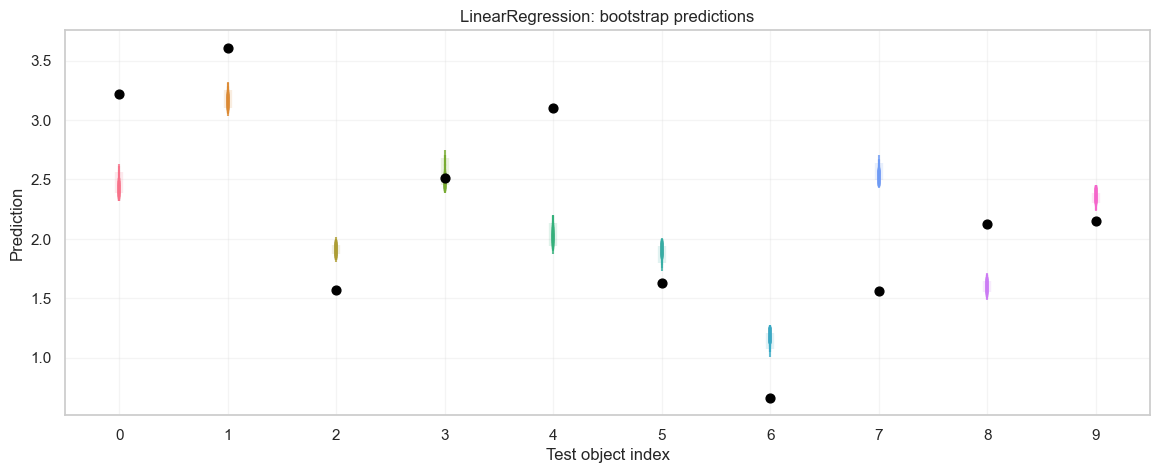

In [100]:
def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title=""):
    """
    plot graphics described above
    Returns predictions_by_object and y_test for further analysis if needed.
    """

    X = np.asarray(X)
    y = _as_numpy_1d(y)
    n_samples = X.shape[0]

    if num_test_objects >= n_samples:
        raise ValueError("num_test_objects must be smaller than the dataset size")

    test_indices = np.random.choice(n_samples, size=num_test_objects, replace=False)
    train_mask = np.ones(n_samples, dtype=bool)
    train_mask[test_indices] = False

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_indices], y[test_indices]

    predictions_by_object = [[] for _ in range(num_test_objects)]

    for _ in range(num_runs):
        bootstrap_indices = np.random.choice(X_train.shape[0], size=X_train.shape[0], replace=True)
        estimator = clone(model)
        estimator.fit(X_train[bootstrap_indices], y_train[bootstrap_indices])
        preds = _as_numpy_1d(estimator.predict(X_test))
        for obj_idx, p in enumerate(preds):
            predictions_by_object[obj_idx].append(p)

    plt.figure(figsize=(14, 5))
    palette = sns.color_palette("husl", n_colors=num_test_objects)
    for obj_idx, preds in enumerate(predictions_by_object):
        if len(preds) == 0:
            continue
        x_vals = np.full(len(preds), obj_idx)
        plt.vlines(
            obj_idx,
            float(np.min(preds)),
            float(np.max(preds)),
            color=palette[obj_idx],
            alpha=0.15,
            linewidth=6,
        )
        plt.scatter(
            x_vals,
            preds,
            color=palette[obj_idx],
            alpha=0.8,
            s=120,
            marker="|",
            linewidths=1.5,
        )
        plt.scatter(obj_idx, y_test[obj_idx], color="black", s=40, zorder=3)

    plt.xticks(range(num_test_objects))
    plt.xlim(-0.5, num_test_objects - 0.5)
    plt.xlabel("Test object index")
    plt.ylabel("Prediction")
    plt.title(title if title else "Bootstrap predictions by test object")
    plt.grid(alpha=0.2)
    plt.show()

    return predictions_by_object, y_test


# пример для задания 11.1
_ = plot_predictions(
    LinearRegression(),
    X,
    y,
    num_runs=50,
    num_test_objects=10,
    title="LinearRegression: bootstrap predictions",
)

__Задание 11.2 (0.5 балла)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат. Это поможет корректно проанализировать масштаб разброса у каждого из этих алгоритмов.

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

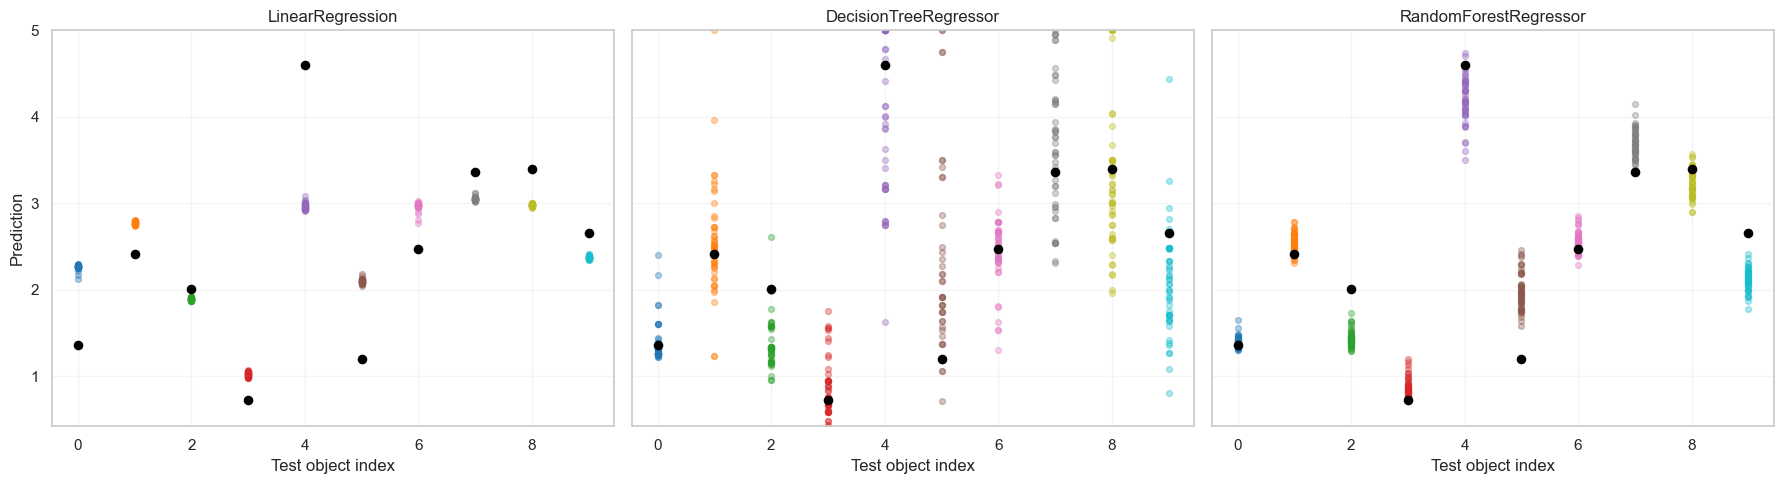

In [101]:
models = [
    ("LinearRegression", LinearRegression()),
    ("DecisionTreeRegressor", DecisionTreeRegressor(random_state=0)),
    ("RandomForestRegressor", RandomForestRegressor(random_state=0, n_estimators=50)),
]

num_runs = 50
num_test_objects = 10

X_arr = np.asarray(X)
y_arr = _as_numpy_1d(y)

rng = np.random.RandomState(0)
test_indices = rng.choice(X_arr.shape[0], size=num_test_objects, replace=False)
train_mask = np.ones(X_arr.shape[0], dtype=bool)
train_mask[test_indices] = False

X_train, y_train = X_arr[train_mask], y_arr[train_mask]
X_test, y_test = X_arr[test_indices], y_arr[test_indices]


def bootstrap_predictions(model, X_train, y_train, X_test, num_runs, rng):
    preds_by_obj = [[] for _ in range(X_test.shape[0])]
    for _ in range(num_runs):
        bootstrap_indices = rng.choice(X_train.shape[0], size=X_train.shape[0], replace=True)
        estimator = clone(model)
        estimator.fit(X_train[bootstrap_indices], y_train[bootstrap_indices])
        preds = _as_numpy_1d(estimator.predict(X_test))
        for obj_idx, pred in enumerate(preds):
            preds_by_obj[obj_idx].append(pred)
    return preds_by_obj


all_predictions = []
for _, model in models:
    preds = bootstrap_predictions(model, X_train, y_train, X_test, num_runs, rng)
    all_predictions.append(preds)

all_values = np.concatenate(
    [np.asarray(preds).ravel() for preds in all_predictions if len(preds) > 0] + [y_test]
)
y_min, y_max = float(all_values.min()), float(all_values.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
palette = sns.color_palette("tab10", n_colors=num_test_objects)

for axis, (name, _), preds_by_obj in zip(axes, models, all_predictions):
    for obj_idx, preds in enumerate(preds_by_obj):
        x_vals = np.full(len(preds), obj_idx)
        axis.scatter(x_vals, preds, color=palette[obj_idx % len(palette)], alpha=0.35, s=18)
        axis.scatter(obj_idx, y_test[obj_idx], color="black", s=35, zorder=3)
    axis.set_title(name)
    axis.set_xlabel("Test object index")
    axis.grid(alpha=0.2)

axes[0].set_ylabel("Prediction")
axes[0].set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

**Ответ:**

- LinearRegression: столбики плотные и узкие вокруг среднего значения, виден высокий bias (систематический сдвиг относительно истинных точек), variance низкий.
- DecisionTreeRegressor: столбики заметно шире, предсказания сильно гуляют между бутстрапами, bias ниже, variance высокий.
- RandomForestRegressor: столбики уже, чем у дерева, variance заметно снижён за счет бэггинга деревьев, bias умеренный.

### Рефлексия по использованию LLM


- Задание 6: 
Промпты: 

"Реализуй функцию для вычисления критерия Джини для двух подмножеств данных. Формула для Джини: Gini = 1 - ∑ (p_i)^2, где p_i — это доля объектов в классе i. Нужно также учесть, что эта функция будет вызываться для каждого возможного разбиения, чтобы выбрать лучший признак.", 

"Реализуй рекурсивную функцию для метода предсказания в дереве решений. На каждом шаге нужно проверять значение признака и переходить в соответствующий подузел. Когда достигается лист, возвращать наиболее частый класс среди объектов в этом листе."
- Задание 10.1: уточнял структуру цикла по бутстрап-выборкам и учет out-of-bag. Промпт: "Нужен ли второй цикл по объектам или можно оставить один цикл по выборкам?".
- Задание 11.1: просил идеи по графику. Промпт: "Как сделать вертикальные столбики предсказаний для каждого тестового объекта и отметить истинные значения черной точкой?".
- Задание 11.2: уточнял, как синхронизировать ось Y. Промпт: "Как построить три графика в ряд с общей осью Y, чтобы корректно сравнить разброс?".